In [1]:
import sys
import os
import datetime 

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import ionolib
import gnss_dtec_map
%matplotlib inline

# IRI Simulation

In [2]:
# Set Default Values
time    = datetime.datetime(2018,12,15,20)
time_0  = time
# engine  = 'PyIRI'  # Victoria Forsythe's PyIRI (https://github.com/victoriyaforsythe/PyIRI)
engine  = 'iri2016' # Michael Hirsch's IRI2016 Python Wrapper (https://github.com/space-physics/iri2016)

output_dir  = os.path.join('output',engine)
profile_dir = os.path.join(output_dir,'profiles')
ionolib.gen_lib.prep_dirs({0:profile_dir},php=False)

map_dir     = os.path.join(output_dir,'maps')
ionolib.gen_lib.prep_dirs({0:map_dir},php=False)

In [3]:
kw_args             = {}
kw_args['engine']   = engine
kw_args['sDate']    = time
kw_args['eDate']    = time
kw_args['hgt_0']    =    0.0
kw_args['hgt_1']    =  600.0
kw_args['hgt_step'] =    3.0

kw_args['lat_0']    =   20.0
kw_args['lat_1']    =   80.0
kw_args['lon_0']    = -130.0
kw_args['lon_1']    =  -50.0
kw_args['lat_step'] =    0.50
kw_args['lon_step'] =    0.50

#kw_args['lat_0']    =   -90.
#kw_args['lat_1']    =    90.
#kw_args['lon_0']    = -180.0
#kw_args['lon_1']    =  180.0

print('Generating 3d Ionosphere...')
iono = ionolib.iono_grid.iono_3d(**kw_args)

print('Adding in TID...')
advance_minutes = (time - time_0).total_seconds()/60.
wave_list = []
wave_list.append(dict(src_lat=78.,src_lon= -75.,amplitude=25,lambda_h=1000,T_minutes=120,advance_minutes=advance_minutes))
iono.generate_wave(wave_list)

Generating 3d Ionosphere...
Adding in TID...


In [4]:
iono.dates

[datetime.datetime(2018, 12, 15, 20, 0)]

In [5]:
# # World
# xlim    = (-180,180)
# ylim    = (-90,90)

# # CONUS
# xlim    = (-130,-56)
# ylim    = (20,55)

# CONUS + Canada
xlim    = (-130,-56)
ylim    = (20,80)

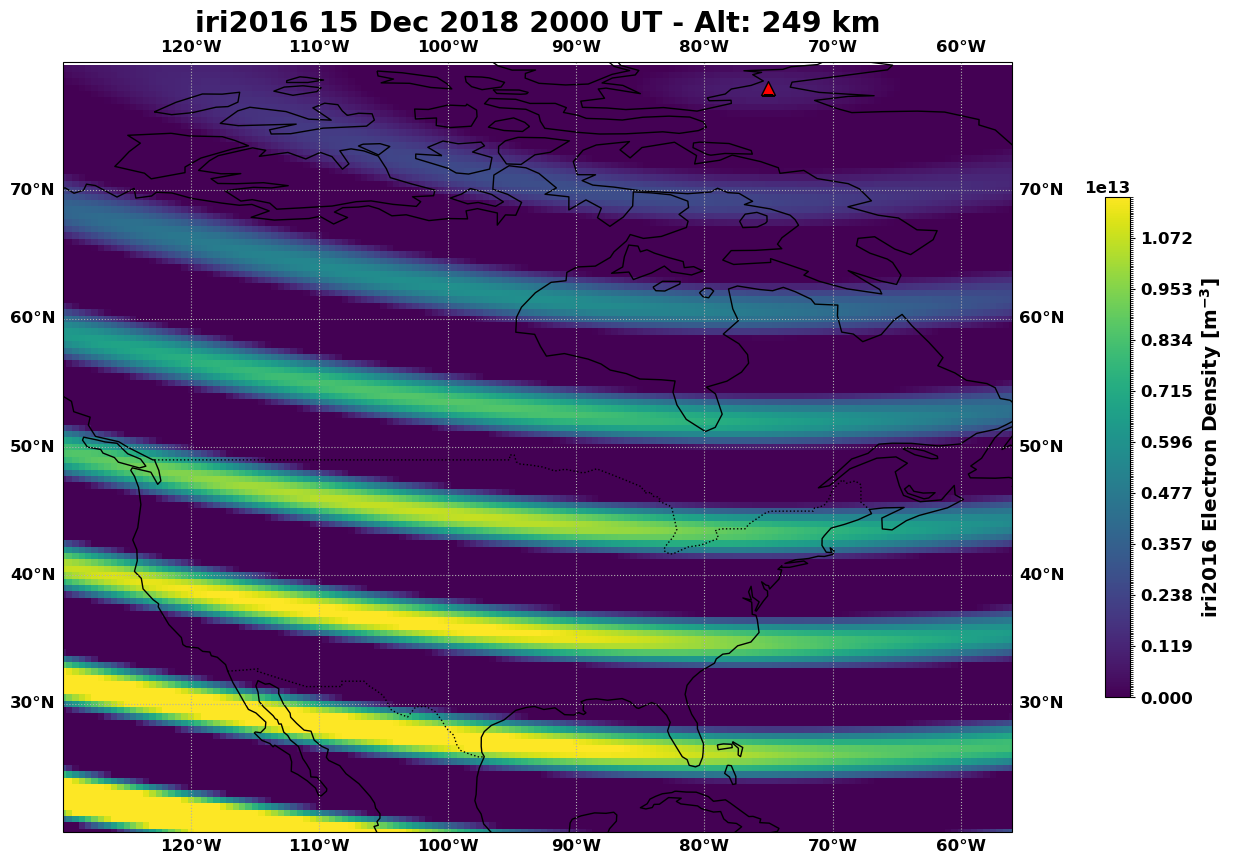

In [6]:
alt=250.
figsize=(16,10)

ds      = iono.iri_dataset
edens   = ds['electron_density'].values
lats    = ds['lat'].values
lons    = ds['lon'].values
alts    = ds['alt'].values
dates   = list(map(pd.to_datetime,ds['date'].values))

alt_inx = np.argmin(np.abs(alts-alt))

scale,ticks,cmap = ionolib.iono_grid.calculate_scale(edens[:,:,:,alt_inx])
bounds      = np.linspace(scale[0],scale[1],256)
norm        = matplotlib.colors.BoundaryNorm(bounds,cmap.N)

dInx = 0
date = iono.dates[dInx]

this_edens  = edens[dInx,:,:]

fig     = plt.figure(figsize=figsize)
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

LONS, LATS  = np.meshgrid(lons,lats)
data        = this_edens[:,:,alt_inx]
pcoll       = ax.pcolormesh(LONS,LATS,data,cmap=cmap,norm=norm)

# Plot Wave Source Locations
if hasattr(iono,'wave_list'):
    for wave in iono.wave_list:
        wlat    = wave['src_lat']
        wlon    = wave['src_lon']
        ax.scatter(wlon,wlat,marker='^',s=100,zorder=110,ec='k',fc='red')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

cbar_label  = iono.engine + r' Electron Density [m$^{-3}$]'
cbar        = fig.colorbar(pcoll,orientation='vertical',shrink=0.65,pad=0.075,ticks=ticks)
cbar.set_label(cbar_label,fontdict={'weight':'bold','size':'large'})

# Plot Title
txt = []
txt.append('{!s} {!s} - Alt: {:.0f} km'.format(iono.engine,
                                               date.strftime('%d %b %Y %H%M UT'),float(alts[alt_inx])))
ax.set_title('\n'.join(txt),fontdict={'weight':'bold','size':'xx-large'})
plt.show()

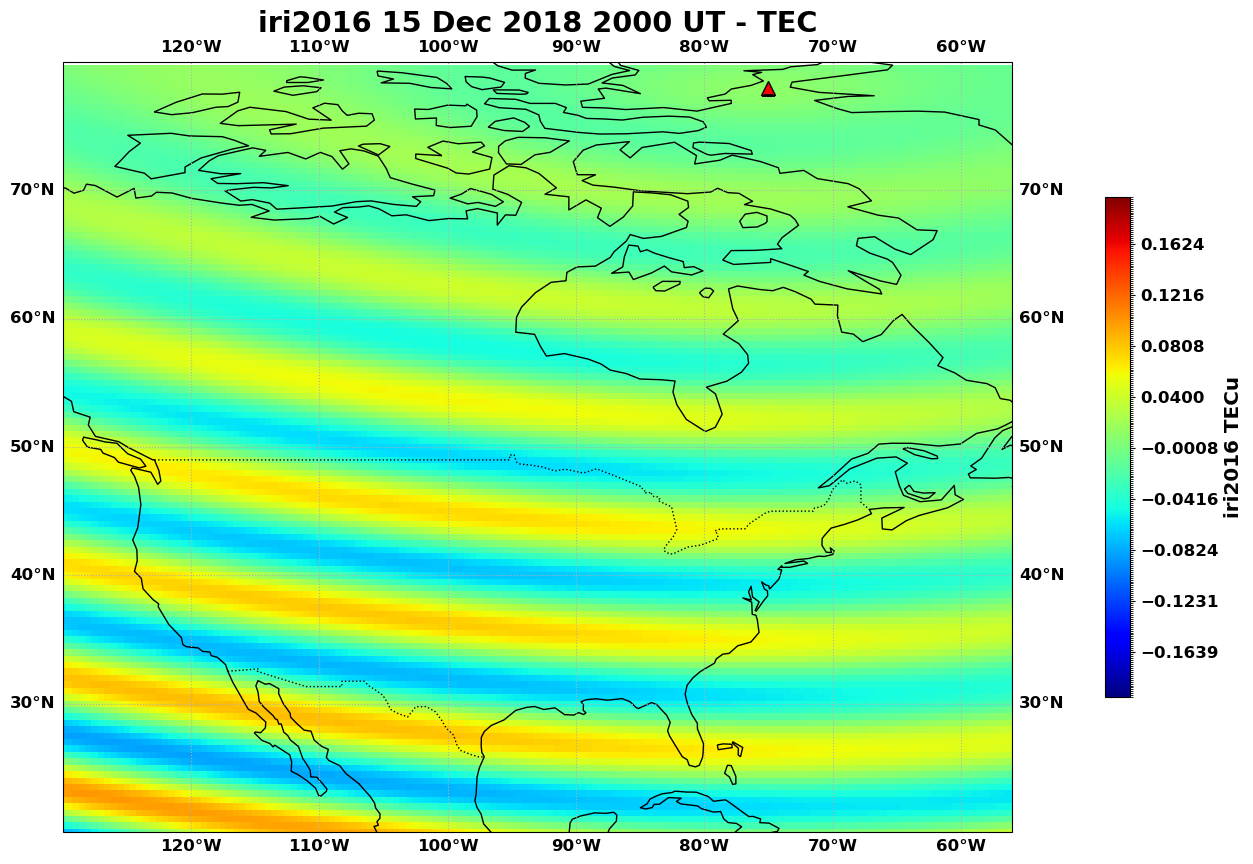

In [7]:
alt=250.
figsize=(16,10)

ds      = iono.iri_dataset
edens   = ds['electron_density'].values
lats    = ds['lat'].values
lons    = ds['lon'].values
alts    = ds['alt'].values
dates   = list(map(pd.to_datetime,ds['date'].values))

scale   = (-0.2,0.2)
ticks   = None
cmap    = matplotlib.cm.jet

bounds      = np.linspace(scale[0],scale[1],256)
norm        = matplotlib.colors.BoundaryNorm(bounds,cmap.N)

dInx = 0
date = iono.dates[dInx]

this_edens  = edens[dInx,:,:]

fig     = plt.figure(figsize=figsize)
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

LONS, LATS  = np.meshgrid(lons,lats)
# data        = this_edens[:,:,alt_inx]
this_TECu   = np.sum(this_edens,axis=2)/1e16
this_dTEC   = this_TECu - this_TECu.mean()
data        = this_dTEC
pcoll       = ax.pcolormesh(LONS,LATS,data,cmap=cmap,norm=norm)

# Plot Wave Source Locations
if hasattr(iono,'wave_list'):
    for wave in iono.wave_list:
        wlat    = wave['src_lat']
        wlon    = wave['src_lon']
        ax.scatter(wlon,wlat,marker='^',s=100,zorder=110,ec='k',fc='red')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

cbar_label  = iono.engine + r' TECu'
cbar        = fig.colorbar(pcoll,orientation='vertical',shrink=0.65,pad=0.075,ticks=ticks)
cbar.set_label(cbar_label,fontdict={'weight':'bold','size':'large'})

# Plot Title
txt = []
txt.append('{!s} {!s} - TEC'.format(iono.engine,
                                               date.strftime('%d %b %Y %H%M UT')))
ax.set_title('\n'.join(txt),fontdict={'weight':'bold','size':'xx-large'})
plt.show()

# GNSS dTEC Data

In [8]:
hsp     = gnss_dtec_map.GNSSdTECMap(time)

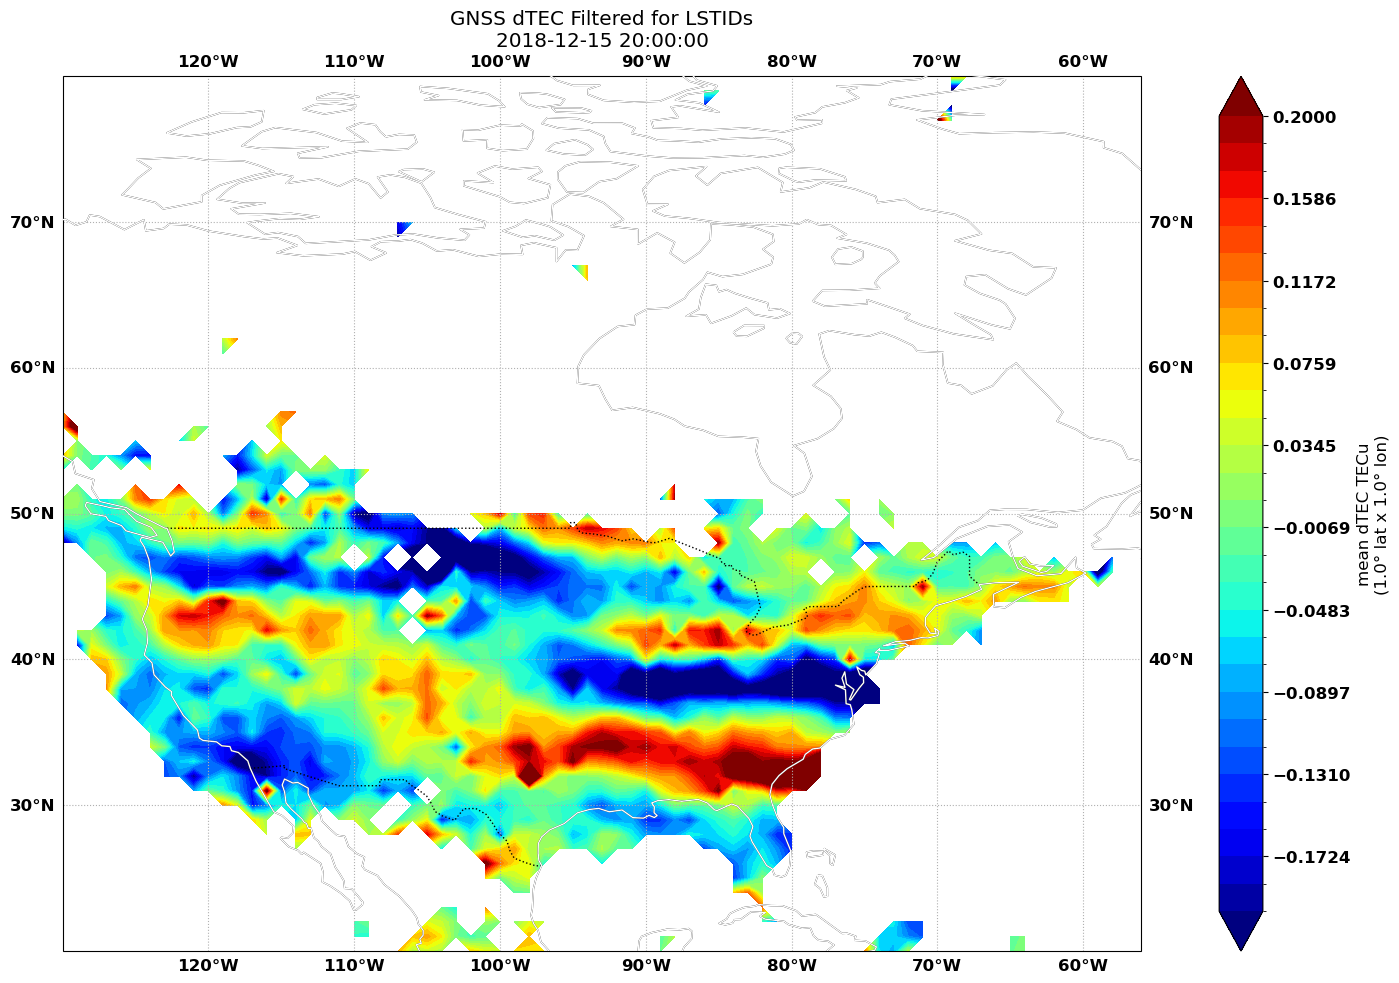

In [10]:
fig     = plt.figure(figsize=(16,10))
ax = hsp.plot_map_ax(fig,subplot=(1,1,1))
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('GNSS dTEC Filtered for LSTIDs\n'+str(date))
fig.tight_layout()
plt.show()